### PARTIE 1 : Vadiane Soreille

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier


In [3]:
df = pd.read_csv("breast_cancer_clean.csv")

In [4]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,perimeter_area_ratio,concavity_concave_ratio,compactness_smoothness_ratio,radius_texture_interaction,perimeter_concavity_interaction
0,1,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,...,2.616665,2.109526,2.296076,2.750622,1.937015,-0.967195,0.361122,2.925849,-0.830185,2.475381
1,1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,...,-0.430444,-0.146749,1.087084,-0.243890,0.281190,-1.587973,-0.559080,-0.285842,0.806803,0.181109
2,1,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,...,1.082932,0.854974,1.955000,1.152255,0.201391,-1.371280,-0.209024,0.917883,1.290994,1.460748
3,1,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,...,3.893397,1.989588,2.175786,6.046041,4.935010,1.196578,0.653323,2.127077,-0.408988,0.832018
4,1,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,...,-0.313395,0.613179,0.729259,-0.868353,-0.397100,-1.479109,0.198430,0.612004,0.124053,1.559379


In [5]:
#separation du dataset en train et test
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Taille du jeu d'entraînement :", X_train.shape)
print("Taille du jeu de test :", X_test.shape)

print("\nDistribution des classes dans le jeu d'entraînement :")
print(y_train.value_counts(normalize=True))

print("\nDistribution des classes dans le jeu de test :")
print(y_test.value_counts(normalize=True))



Taille du jeu d'entraînement : (455, 35)
Taille du jeu de test : (114, 35)

Distribution des classes dans le jeu d'entraînement :
diagnosis
0    0.628571
1    0.371429
Name: proportion, dtype: float64

Distribution des classes dans le jeu de test :
diagnosis
0    0.622807
1    0.377193
Name: proportion, dtype: float64


In [23]:
#score du modele aleatoire
dummy_random = DummyClassifier(strategy="uniform")
dummy_random.fit(X_train, y_train)

y_pred_random = dummy_random.predict(X_test)
dummy_accuracy = accuracy_score(y_test, y_pred_random)
print(f"Dummy Classifier Accuracy: {dummy_accuracy:.4f}")


Dummy Classifier Accuracy: 0.5263


In [24]:
#score du modele qui predit toujours la classe majoritaire
dummy_majority = DummyClassifier(strategy="most_frequent")
dummy_majority.fit(X_train, y_train)

y_pred_dummy = dummy_majority.predict(X_test)
accuracy_majority = accuracy_score(y_test, y_pred_dummy)
print(f"Dummy Classifier Accuracy: {accuracy_majority:.4f}")



Dummy Classifier Accuracy: 0.6316


In [8]:
#fonction d'evaluation des modeles 

def evaluate_model(y_test, y_pred):
    print("Evaluation du modèle :\n")

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")    
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}\n")

    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))

    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred))


models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}



results = []

print("\n===============Résultats des modèles :============================\n")

for name, model in models.items():

    print(f"Modèle: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    evaluate_model(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print("\n=====================Résumé des performances des modèles :=====================\n")
print(results_df.sort_values(by="F1 Score", ascending=False))



===============Résultats des modèles :============================

Modèle: Logistic Regression
Evaluation du modèle :

Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9535
F1 Score: 0.9762

Matrice de confusion :
[[71  0]
 [ 2 41]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Modèle: k-NN
Evaluation du modèle :

Accuracy: 0.9649
Precision: 0.9535
Recall: 0.9535
F1 Score: 0.9535

Matrice de confusion :
[[69  2]
 [ 2 41]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       

# Partie 2 - Implementation du modele

In [18]:
# 4. Implémentation de 5 algorithmes
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'K-NN': KNeighborsClassifier()
}

# Entraînement et prédiction rapide
results = {}

for name, model in models.items():
    print(f"\n Entraînement : {name}")
    
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Stockage
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    # Métriques basiques
    accuracy = accuracy_score(y_test, y_pred) # Accurcy: score exactitide, il est habiter lorsque les data sont deseclibrer
    print(f"   Accuracy : {accuracy:.3f}")


 Entraînement : Logistic Regression
   Accuracy : 0.982

 Entraînement : Decision Tree
   Accuracy : 0.930

 Entraînement : Random Forest
   Accuracy : 0.965

 Entraînement : Gradient Boosting
   Accuracy : 0.965

 Entraînement : SVM
   Accuracy : 0.974

 Entraînement : K-NN
   Accuracy : 0.956


In [19]:
# 3.2 Évaluation de tous les modèles
model_metrics = {
    name: evaluate_model(y_test,
                           res['y_pred'],
                           res['y_pred_proba'],
                           name)
    for name, res in results.items()
}

# Affichage synthétique des résultats
for name, m in model_metrics.items():
    print(f"\n{'='*40}\nÉVALUATION : {name}\n{'='*40}")
    print(f"Acc  : {m['accuracy']:.3f}")
    print(f"Prec : {m['precision']:.3f}")
    print(f"Rec  : {m['recall']:.3f}")
    print(f"F1   : {m['f1']:.3f}")
    if 'roc_auc' in m:
        print(f"AUC  : {m['roc_auc']:.3f}")

    tn, fp, fn, tp = m['confusion_matrix'].ravel()
    print(f"CM   : [[TN={tn}, FP={fp}] [FN={fn}, TP={tp}]]")



ÉVALUATION : Logistic Regression
Acc  : 0.982
Prec : 0.976
Rec  : 0.976
F1   : 0.976
AUC  : 0.996
CM   : [[TN=71, FP=1] [FN=1, TP=41]]

ÉVALUATION : Decision Tree
Acc  : 0.930
Prec : 0.905
Rec  : 0.905
F1   : 0.905
AUC  : 0.925
CM   : [[TN=68, FP=4] [FN=4, TP=38]]

ÉVALUATION : Random Forest
Acc  : 0.965
Prec : 0.975
Rec  : 0.929
F1   : 0.951
AUC  : 0.997
CM   : [[TN=71, FP=1] [FN=3, TP=39]]

ÉVALUATION : Gradient Boosting
Acc  : 0.965
Prec : 1.000
Rec  : 0.905
F1   : 0.950
AUC  : 0.995
CM   : [[TN=72, FP=0] [FN=4, TP=38]]

ÉVALUATION : SVM
Acc  : 0.974
Prec : 0.976
Rec  : 0.952
F1   : 0.964
AUC  : 0.995
CM   : [[TN=71, FP=1] [FN=2, TP=40]]

ÉVALUATION : K-NN
Acc  : 0.956
Prec : 0.974
Rec  : 0.905
F1   : 0.938
AUC  : 0.983
CM   : [[TN=71, FP=1] [FN=4, TP=38]]


In [20]:
# 5. Analyse comparative

# Extraire les métriques en listes
models_list = list(model_metrics.keys())
accuracy_list = [model_metrics[m]['accuracy'] for m in models_list]
precision_list = [model_metrics[m]['precision'] for m in models_list]
recall_list = [model_metrics[m]['recall'] for m in models_list]
f1_list = [model_metrics[m]['f1'] for m in models_list]
roc_auc_list = [model_metrics[m].get('roc_auc', None) for m in models_list]

# Créer le DataFrame
results_df = pd.DataFrame({
    'Model': models_list,
    'Accuracy': accuracy_list,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1-Score': f1_list,
    'ROC-AUC': roc_auc_list
})

# Trier par F1-Score
results_df = results_df.sort_values('F1-Score', ascending=False)

# Format avec 2 chiffres après la virgule
float_format = lambda x: f"{x:.2f}" if isinstance(x, (int, float)) else x

print("\nClassement des modèles")
print(results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].to_string(index=False, float_format=float_format))



Classement des modèles
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.98       0.98    0.98      0.98     1.00
                SVM      0.97       0.98    0.95      0.96     0.99
      Random Forest      0.96       0.97    0.93      0.95     1.00
  Gradient Boosting      0.96       1.00    0.90      0.95     1.00
               K-NN      0.96       0.97    0.90      0.94     0.98
      Decision Tree      0.93       0.90    0.90      0.90     0.92


#### Visualisation des résultats

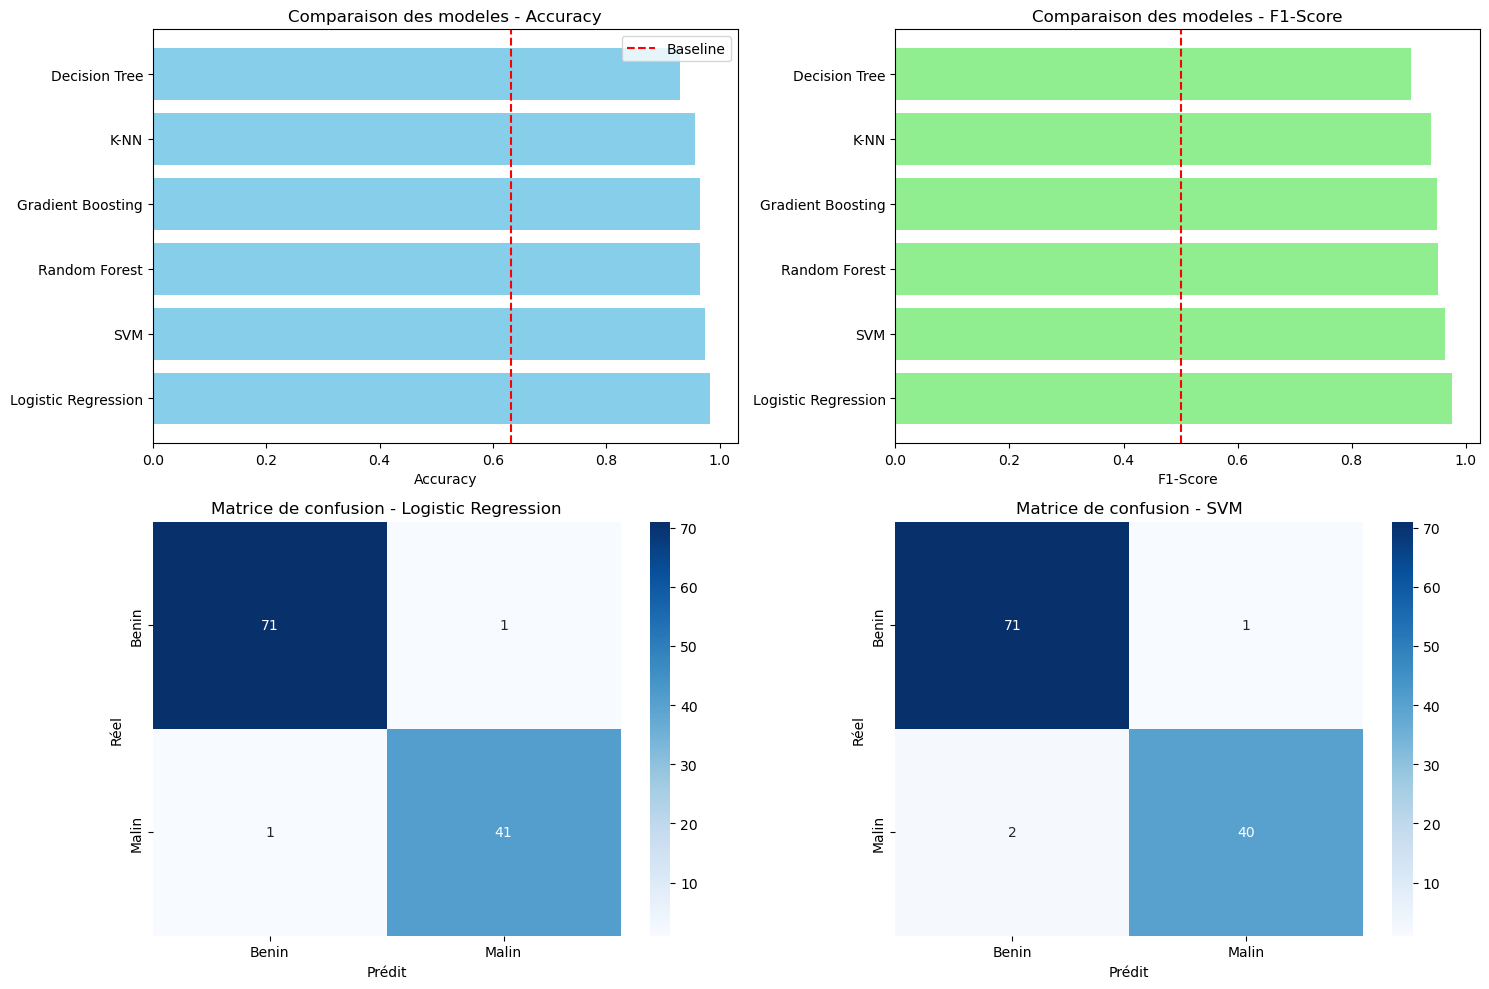


Meilleur modèle: Logistic Regression (F1-Score: 0.98)


In [26]:
# Visualisation des résultats
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Graphique 1: Accuracy
axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Comparaison des modeles - Accuracy')
axes[0, 0].axvline(x=accuracy_majority, color='red', linestyle='--', label='Baseline')
axes[0, 0].legend()

# Graphique 2: F1-Score
axes[0, 1].barh(results_df['Model'], results_df['F1-Score'], color='lightgreen')
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('Comparaison des modeles - F1-Score')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', label='Seuil acceptable')

# Graphique 3: Matrices de confusion pour les 2 meilleurs modèles
top_models = results_df.head(2)['Model'].values

for idx, model_name in enumerate(top_models):
    ax = axes[1, idx]
    cm = model_metrics[model_name]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benin', 'Malin'],
                yticklabels=['Benin', 'Malin'])
    ax.set_title(f'Matrice de confusion - {model_name}')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()

# Identification du meilleur modèle
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\nMeilleur modèle: {best_model_name} (F1-Score: {results_df.iloc[0]['F1-Score']:.2f})")

# Partie 3 - Cross Validation

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [28]:
# Selection des 3 meilleurs modeles pour validation croisee
top_3_models = results_df.head(3)['Model'].values

cv_scores = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name in top_3_models:
    model = results[model_name]['model']
    
    # Scores de validation croisée
    cv_acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1')
    
    cv_scores[model_name] = {
        'Accuracy_mean': cv_acc.mean(),
        'Accuracy_std': cv_acc.std(),
        'F1_mean': cv_f1.mean(),
        'F1_std': cv_f1.std()
    }
    
    print(f"\n{model_name}:")
    print(f"  Accuracy: {cv_acc.mean():.2f} ({cv_acc.std():.2f})")
    print(f"  F1-Score: {cv_f1.mean():.2f} ({cv_f1.std():.2f})")



Logistic Regression:
  Accuracy: 0.98 (0.01)
  F1-Score: 0.97 (0.02)

SVM:
  Accuracy: 0.97 (0.01)
  F1-Score: 0.96 (0.01)

Random Forest:
  Accuracy: 0.96 (0.01)
  F1-Score: 0.95 (0.02)


#### Optimisation des hyperparamètres

In [33]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [29]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale','auto']
}

In [34]:
#  a) Comparer GridSearchCV et Randomizer
def comparer(model, param_grid, X, y):

    # GridSearchCV
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid_search.fit(X, y)
    grid_best_params = grid_search.best_params_
    grid_best_score = grid_search.best_score_

    # RandomizedSearchCV
    randomized_search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=5, scoring='f1', n_jobs=-1, random_state=42)
    randomized_search.fit(X, y)
    random_best_params = randomized_search.best_params_
    random_best_score = randomized_search.best_score_

    print(f"GridSearchCV: Best F1 Score: {grid_best_score:.4f}, Best Params: {grid_best_params}")
    print(f"RandomizedSearchCV: Best F1 Score: {random_best_score:.4f}, Best Params: {random_best_params}")

In [35]:
comparer(RandomForestClassifier(), param_grid_rf, X_train, y_train)
comparer(SVC(), param_grid_svc, X_train, y_train)

GridSearchCV: Best F1 Score: 0.9560, Best Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
RandomizedSearchCV: Best F1 Score: 0.9551, Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
GridSearchCV: Best F1 Score: 0.9651, Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
RandomizedSearchCV: Best F1 Score: 0.9651, Best Params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
